# I. Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [85]:
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

# II. Khám phá dữ liệu

## 1. Mô tả dữ liệu

In [19]:
print("Kích thước của bộ dữ liệu:", df.shape)

Kích thước của bộ dữ liệu: (9994, 21)


In [20]:
print("5 dòng đầu tiên:",df.head(),sep="\n")
print("\n5 dòng cuối cùng:",df.tail(),sep="\n")

5 dòng đầu tiên:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID    Customer Name    Segment        Country             City       State  Postal Code Region       Product ID         Category Sub-Category                                       Product Name     Sales  Quantity  Discount    Profit
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky        42420  South  FUR-BO-10001798        Furniture    Bookcases                  Bush Somerset Collection Bookcase  261.9600         2      0.00   41.9136
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520      Claire Gute   Consumer  United States        Henderson    Kentucky        42420  South  FUR-CH-10000454        Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400         3      0.00  219.5820
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second

In [40]:
print("\n--- Thông tin kiểu dữ liệu và bộ nhớ của 10 biến đầu ---")
print(df[df.columns[:10]].info())


--- Thông tin kiểu dữ liệu và bộ nhớ của 10 biến đầu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Row ID         9994 non-null   int64 
 1   Order ID       9994 non-null   object
 2   Order Date     9994 non-null   object
 3   Ship Date      9994 non-null   object
 4   Ship Mode      9994 non-null   object
 5   Customer ID    9994 non-null   object
 6   Customer Name  9994 non-null   object
 7   Segment        9994 non-null   object
 8   Country        9994 non-null   object
 9   City           9994 non-null   object
dtypes: int64(1), object(9)
memory usage: 780.9+ KB
None


In [16]:
print("\n--- Thông tin kiểu dữ liệu và bộ nhớ của các biến còn lại ---")
print(df[df.columns[10:]].info())


--- Thông tin kiểu dữ liệu và bộ nhớ của các biến còn lại ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         9994 non-null   object 
 1   Postal Code   9994 non-null   int64  
 2   Region        9994 non-null   object 
 3   Product ID    9994 non-null   object 
 4   Category      9994 non-null   object 
 5   Sub-Category  9994 non-null   object 
 6   Product Name  9994 non-null   object 
 7   Sales         9994 non-null   float64
 8   Quantity      9994 non-null   int64  
 9   Discount      9994 non-null   float64
 10  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 859.0+ KB
None


In [8]:
print("\n--- Danh sách các cột ---")
print(df.columns.tolist())


--- Danh sách các cột ---
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


Thời gian: Order Date, Ship Date.

Khách hàng: Customer ID, Customer Name, Segment.

Địa lý: Country, Region, State, City.

Sản phẩm: Category, Sub-Category, Product Name.

Kinh doanh: Sales, Quantity, Discount, Profit.

## 2. Kiểm tra chất lượng dữ liệu

In [17]:
print("\n--- Kiểm tra giá trị bị thiếu (Null/NaN) ---")
missing_values = df.isnull().sum()
if missing_values[missing_values > 0].any():
    print("Các cột có giá trị bị thiếu:")
    print(missing_values[missing_values > 0])
else:
    print("Không có giá trị bị thiếu trong bộ dữ liệu.")



--- Kiểm tra giá trị bị thiếu (Null/NaN) ---
Không có giá trị bị thiếu trong bộ dữ liệu.


In [18]:
print("\n--- Kiểm tra dòng trùng lặp hoàn toàn ---")
duplicates = df[df.duplicated()]
print("Số dòng trùng:", duplicates.shape[0])

if not duplicates.empty:
    print("\nCác dòng bị trùng:")
    print(duplicates.head(5))


--- Kiểm tra dòng trùng lặp hoàn toàn ---
Số dòng trùng: 0


In [28]:
# Kiểm tra tính nhất quán của các cột định danh
print("\n Số lượng đơn hàng duy nhất ",df['Order ID'].nunique())
print(" Số lượng khách hàng duy nhất ",df['Customer ID'].nunique())

# Lợi nhuận âm có hợp lý không? (Có, là lỗ). Doanh thu âm có hợp lý không? (Không).
negative_sales = df[df['Sales'] < 0]
print(f" Số giao dịch có doanh thu âm: {len(negative_sales)}")


 Số lượng đơn hàng duy nhất  5009
 Số lượng khách hàng duy nhất  793
 Số giao dịch có doanh thu âm: 0


In [37]:
print("\n--- Kiểu dữ liệu của các cột ---",)
display(df.dtypes)


--- Kiểu dữ liệu của các cột ---


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [73]:

# Select numeric data
numeric_data = df[['Sales', 'Quantity', 'Discount', 'Profit']].select_dtypes(include='number').columns

# Select categorical data
categorical_data = df[['Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']].select_dtypes(include=['O']).columns

print("\n--- Thống kê mô tả cho các biến số (Numerical) ---")
print(df[numeric_data].describe())

print("\n--- Thống kê mô tả các biến phân loại (Categorical) ---")
display(df[categorical_data].describe())


--- Thống kê mô tả cho các biến số (Numerical) ---
              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000

--- Thống kê mô tả các biến phân loại (Categorical) ---


,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,4,793,3,531,49,4,1862,3,17,1850
top,Standard Class,WB-21850,Consumer,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,5968,37,5191,915,2001,3203,19,6026,1523,48


## 3. Khám phá dữ liệu

### A. Phân tích đơn biến

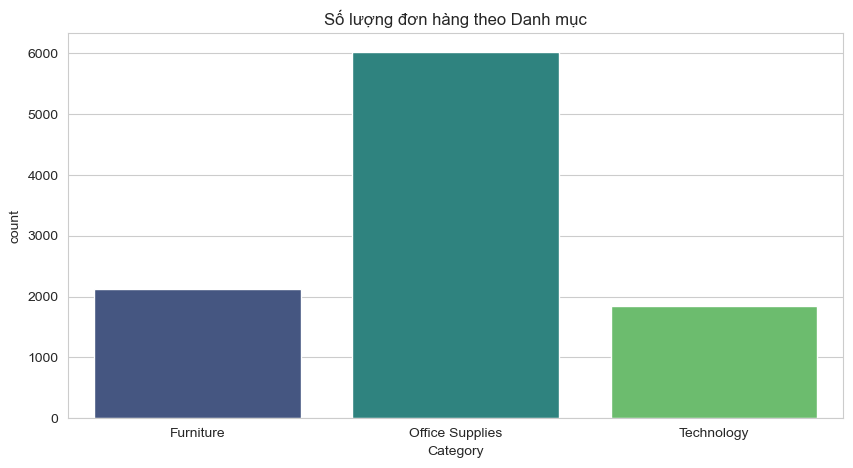

In [31]:
# Phân bố của biến phân loại: Category (Danh mục sản phẩm)
plt.figure(figsize=(10, 5))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Số lượng đơn hàng theo Danh mục')
plt.show()

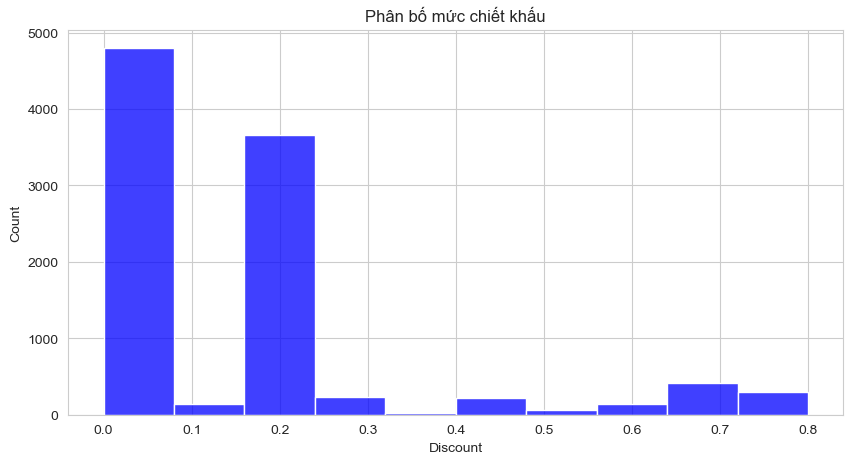

In [32]:
# Phân bố của biến số: Discount (Chiết khấu)
plt.figure(figsize=(10, 5))
sns.histplot(df['Discount'], bins=10, kde=False, color='blue')
plt.title('Phân bố mức chiết khấu')
plt.show()

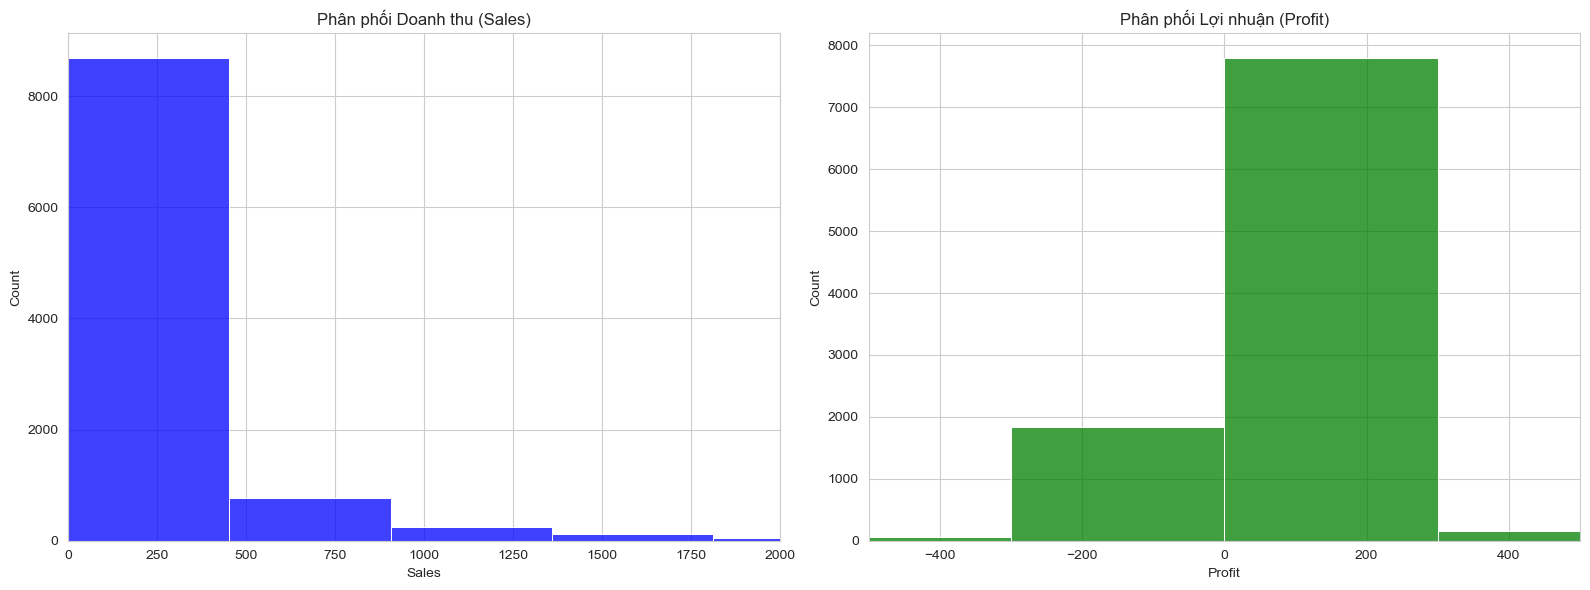

In [33]:
# Phân phối của Lợi nhuận (Profit) và Doanh thu (Sales)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['Sales'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Phân phối Doanh thu (Sales)')
axes[0].set_xlim(0, 2000) # Giới hạn trục x để nhìn rõ hơn vì dữ liệu thường bị lệch phải

sns.histplot(df['Profit'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Phân phối Lợi nhuận (Profit)')
axes[1].set_xlim(-500, 500) # Giới hạn để xem vùng tập trung chính

plt.tight_layout()
plt.show()

### B. Phân tích đa biến

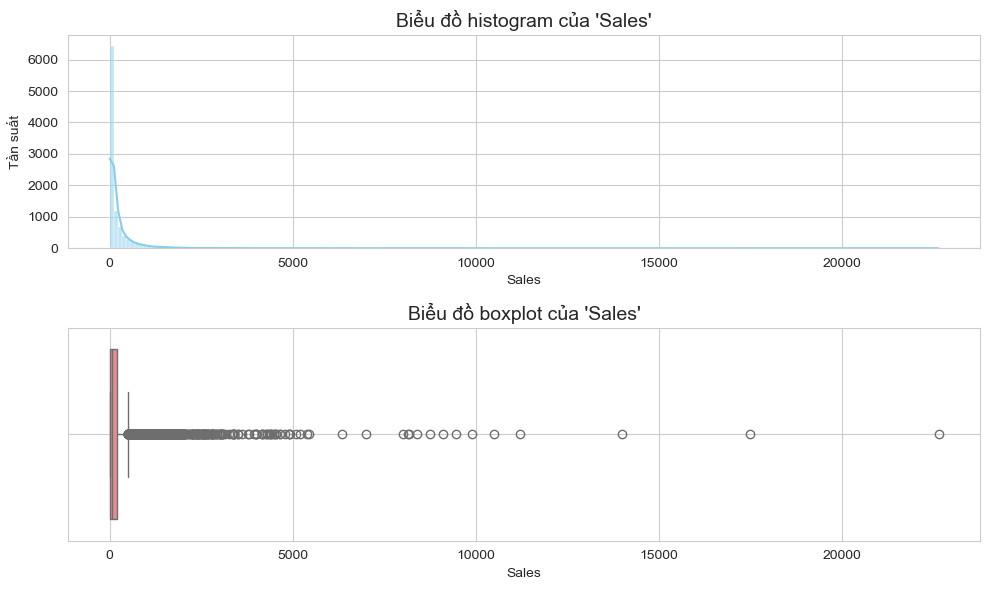

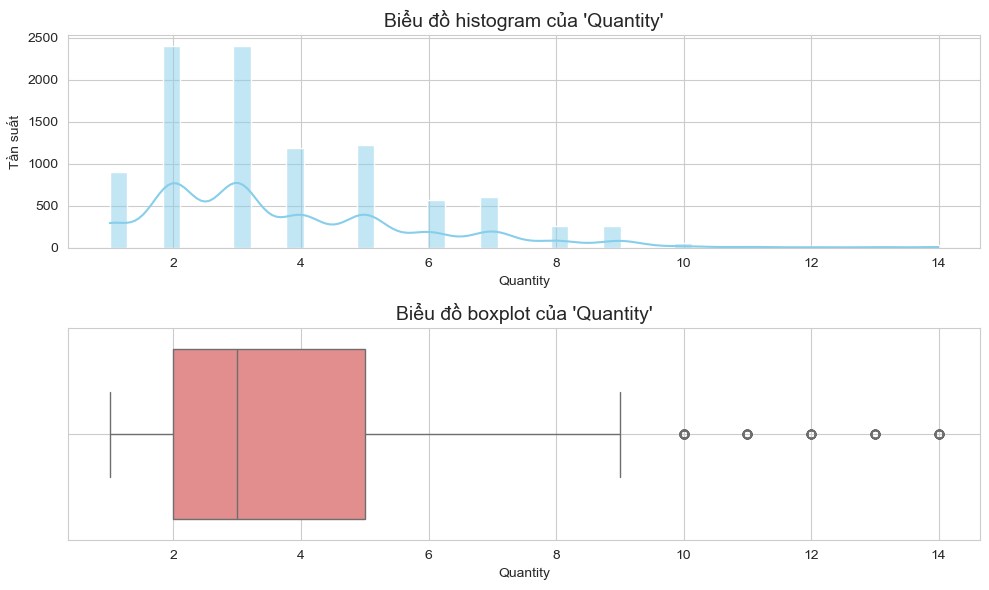

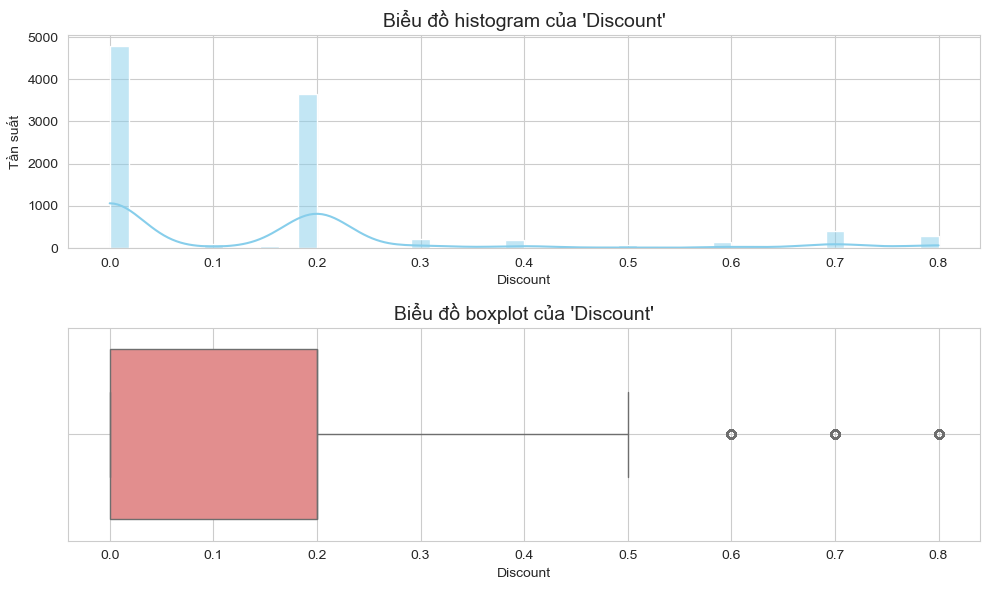

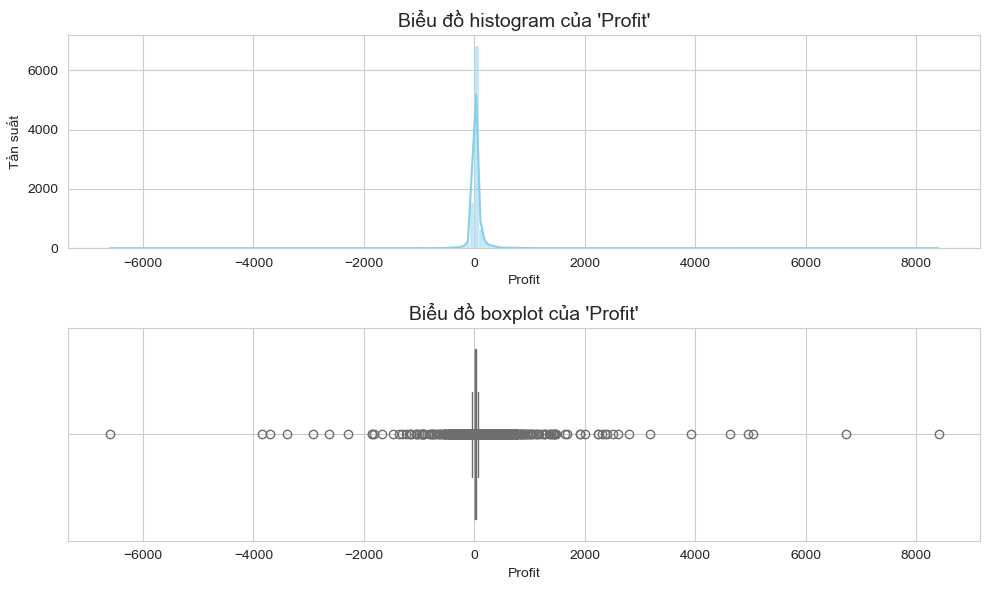

In [75]:
for col in numeric_data:
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))  # 2 hàng, 1 cột

    # Biểu đồ phân bố (Histogram + KDE)
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Biểu đồ histogram của '{col}'", fontsize=14)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Tần suất")
    axes[0].grid(True)

    # Biểu đồ hộp (Boxplot)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f"Biểu đồ boxplot của '{col}'", fontsize=14)
    axes[1].set_xlabel(col)
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

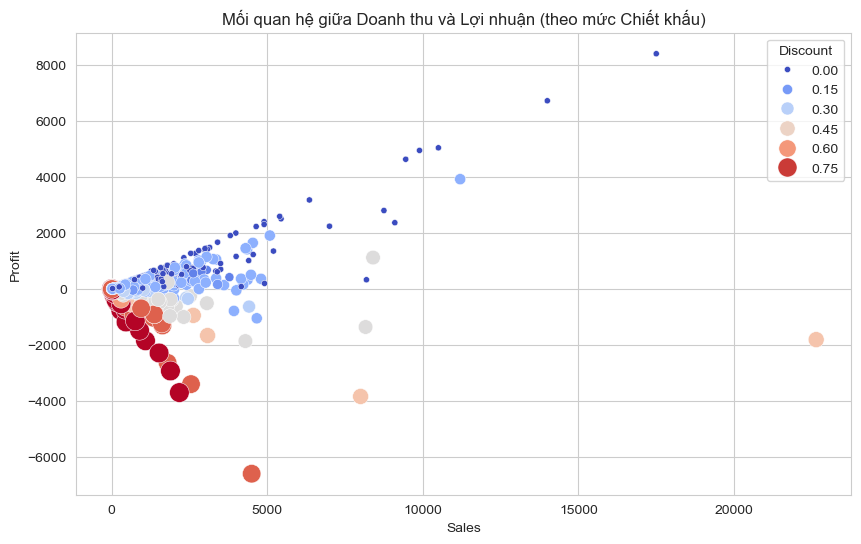

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Discount', size='Discount', sizes=(20, 200), palette='coolwarm')
plt.title('Mối quan hệ giữa Doanh thu và Lợi nhuận (theo mức Chiết khấu)')
plt.show()

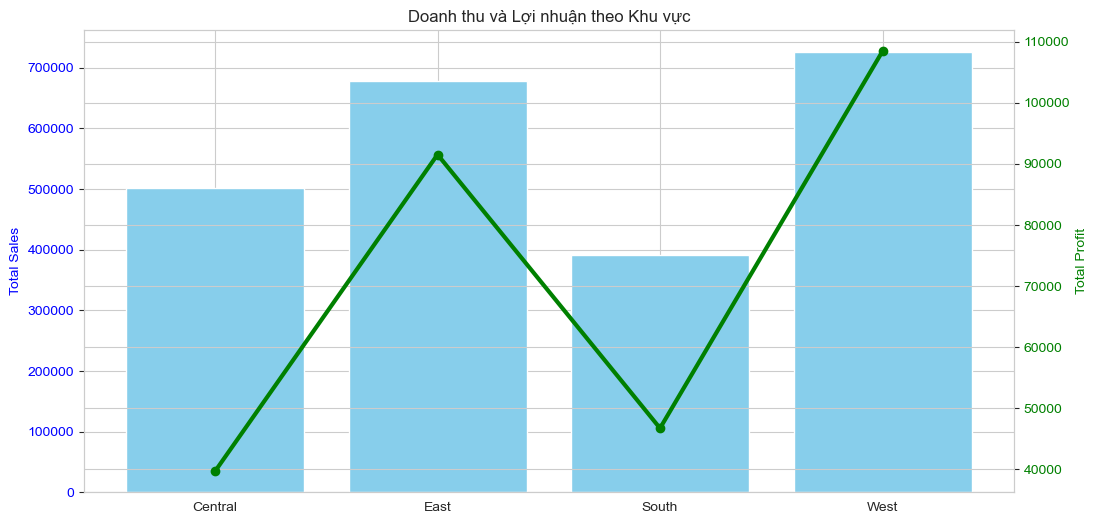

In [42]:
# Gom nhóm dữ liệu
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Vẽ biểu đồ kép
fig, ax1 = plt.subplots(figsize=(12, 6))

# Cột Sales
ax1.bar(region_analysis['Region'], region_analysis['Sales'], color='skyblue', label='Sales')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Đường Profit
ax2 = ax1.twinx()
ax2.plot(region_analysis['Region'], region_analysis['Profit'], color='green', marker='o', linewidth=3, label='Profit')
ax2.set_ylabel('Total Profit', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Doanh thu và Lợi nhuận theo Khu vực')
plt.show()

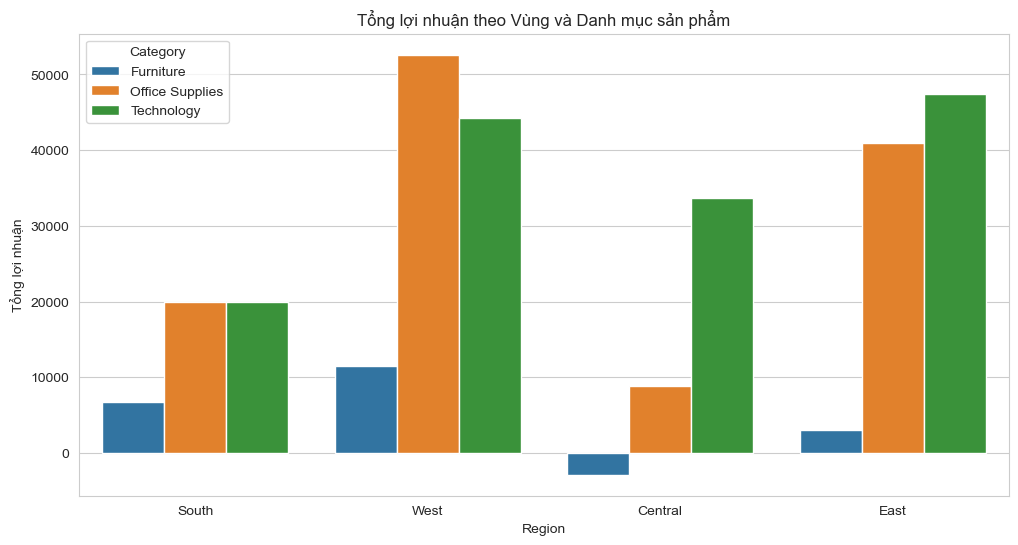

In [43]:
# Lợi nhuận theo Vùng (Region) và Danh mục (Category)
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Profit', hue='Category', data=df, estimator=np.sum, errorbar=None)
plt.title('Tổng lợi nhuận theo Vùng và Danh mục sản phẩm')
plt.ylabel('Tổng lợi nhuận')
plt.show()

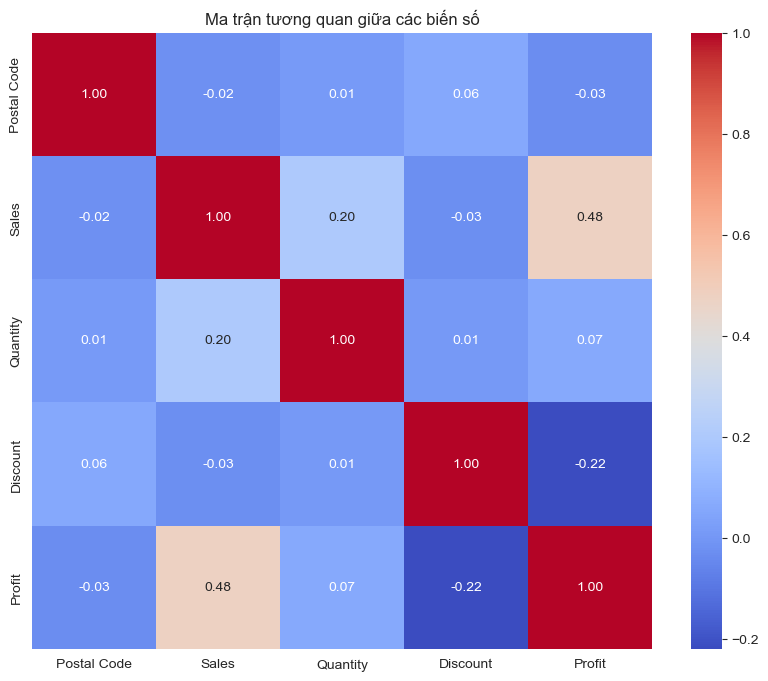

In [65]:
# Chỉ lấy các cột số
numeric_df = df[['Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']].select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

### C. Phân tích chuỗi thời gian

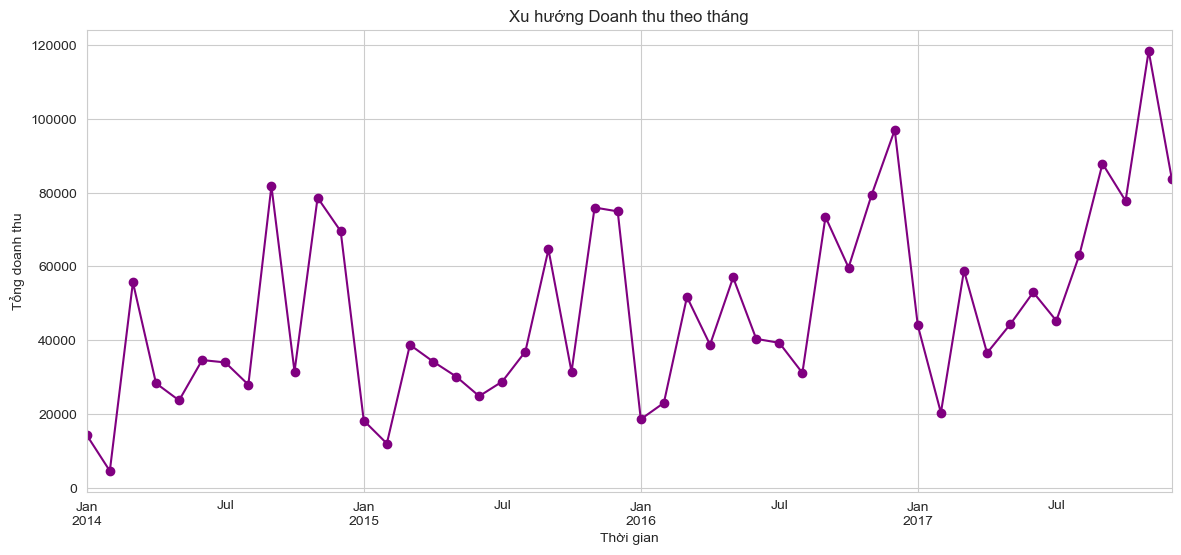

In [45]:
# Chuyển đổi cột Order Date sang datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Nhóm theo tháng để xem xu hướng
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

# Vẽ biểu đồ xu hướng
plt.figure(figsize=(14, 6))
monthly_sales.plot(marker='o', color='purple')
plt.title('Xu hướng Doanh thu theo tháng')
plt.ylabel('Tổng doanh thu')
plt.xlabel('Thời gian')
plt.show()